<a href="https://colab.research.google.com/github/type3005/-/blob/main/%E0%B8%AA%E0%B8%B3%E0%B9%80%E0%B8%99%E0%B8%B2%E0%B8%82%E0%B8%AD%E0%B8%87_FINAL_PRO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 ธุรกิจสหกรณ์ออมทรัพย์ (Savings Cooperative)

ระบบจำลองบัญชีสหกรณ์ออมทรัพย์ ครอบคลุมการ **ฝาก – ถอน – โอน** โดยสมาชิกทำธุรกรรมได้ทีละรายการ พร้อมตรวจสอบยอดเงินคงเหลือให้เพียงพอก่อนทำรายการทุกครั้ง และคำนวณดอกเบี้ยจากยอดเงินคงเหลือในบัญชีเมื่อสิ้นปี

---

## 📑 สารบัญ

| ส่วน | หัวข้อ |
|:---:|---|
| 0 | Import เพื่อเรียกใช้งานชุดคำสั่ง / ฟังก์ชันสำเร็จรูป |
| 1 | เตรียม Class และฟังก์ชัน |
| 2 | ทดสอบฟังก์ชันทีละตัว ก่อนประกอบเป็นกระบวนการ |
| 3 | ฟังก์ชันอธิบายขั้นตอนคำนวณรายการ |
| 4 | จำลอง "ลูกค้า 1 คนเดินเข้าธนาคาร" แบบ step-by-step |
| 5 | จำลองลูกค้าหลายคนเดินเข้าธนาคารต่อเนื่องกัน |
| 6 | สรุปผล — ยืนยันว่าฟังก์ชันคืนค่าถูกต้องและใช้ต่อได้จริง |
| 7 | ตารางลูกค้า |
| 8 | ตารางธุรกรรม |
| 9 | สรุปผลรวม 300 รายการ |
| 10 | SQL.db |
| 11 | Pandas |
| 12 | SQL |
| 13 | กราฟสรุปข้อมูล |
| 14 | สรุปผลการวิเคราะห์ |


## สมาชิก

| คนที่ | ชื่อ |  รหัสนักศึกษา  |  
|:---:|---|---|
| 1 | นางสาวพิทยาภรณ์ อึ้งธนารัตน์ |  683020054-9 |
| 2 | นางสาวณัฐชานันท์ ทองสุก |  683020242-8 |
| 3 | นายชัยวัฒน์ นนทมาตร |  683020568-8  |
| 4 | นายนันธวัฒน์ ฉายาวรรณ  | 683020578-5  |
| 5 | นางสาววิชญาพร แผงบุดดา  | 683020593-9 |



# Import เพื่อ เรียกใช้งานชุดคำสั่ง หรือฟังก์ชันสำเร็จรูป

In [ ]:
import random
import time
from datetime import datetime, timedelta
!pip install Faker
from faker import Faker
fake = Faker("th_TH")
random.seed(1)
import pandas as pd
import matplotlib, os, shutil
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [ ]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!



# ส่วนที่ 1 — เตรียม Class และฟังก์ชัน

มีทั้งหมด 3 คลาส คือ

1. **Class Member** (สมาชิก) — รหัสสมาชิก, ชื่อสมาชิก, เลขบัตรประจำตัวประชาชน, เบอร์โทรศัพท์
2. **Class Account** (บัญชีออมทรัพย์) — เลขบัญชี, ยอดเงินคงเหลือ, เจ้าของบัญชี, ดอกเบี้ยต่อปี
3. **Class Transaction** (ธุรกรรม) — หมายเลขธุรกรรม, บัญชี, ประเภทธุรกรรม, จำนวนเงิน, บัญชีปลายทาง

In [ ]:
class Member:
    """ข้อมูลสมาชิกธนาคารออมทรัพย์"""

    def __init__(
        self,
        member_id,
        customer_name,
        citizen_id=None,
        phone_number=None,
    ):
        self.member_id = member_id
        self.customer_name = customer_name
        self.citizen_id = citizen_id
        self.phone_number = phone_number

    # แสดงข้อมูลสมาชิก
    def get_info(self):
        return (
            f"ลูกค้า ID: {self.member_id} | ชื่อ: {self.customer_name} | "
            f"เลขบัตรประชาชน: {self.citizen_id} | เบอร์โทร: {self.phone_number}"
        )

    # อัปเดตข้อมูลส่วนตัว
    def update_phone(self, new_phone):
        self.phone_number = new_phone

In [ ]:
class Account:
    """บัญชีออมทรัพย์"""

    def __init__(
        self,
        account_number,
        balance,
        owner,
        interest_rate=0.015,
    ):
        self.account_number = account_number
        self.balance = float(balance)
        self.owner = owner
        self.interest_rate = interest_rate

    def deposit(self, amount):
        """ฝากเงิน: balance = balance + amount"""
        self.balance += amount
        return "ฝากเงินสำเร็จ"

    def withdraw(self, amount):
        """ถอนเงิน: ตรวจสอบ balance >= amount"""
        if self.balance < amount:
            return f"ยอดเงินไม่พอ (มีอยู่ {self.balance:,.2f} บาท)"

        self.balance -= amount
        return "ถอนเงินสำเร็จ"

    def transfer(self, target_account, amount):
        """โอนเงิน: ตัดบัญชีต้นทาง และบวกเข้าบัญชีปลายทาง"""
        if self.balance < amount:
            return f"ยอดเงินไม่พอโอน (มีอยู่ {self.balance:,.2f} บาท)"

        self.balance -= amount
        target_account.balance += amount
        return "โอนเงินสำเร็จ"

    def apply_interest(self):
        """คำนวณดอกเบี้ยและบวกเข้ายอดคงเหลือ"""
        interest = self.balance * self.interest_rate
        self.balance += interest
        return interest

In [ ]:
def generate_transaction_data(txn_id):
    """ฟังก์ชันสุ่มคิว 40 รายการต่อวัน (รับแค่ txn_id)"""
    base_date = datetime(2026, 8, 22)
    day_idx = 0
    total_items = 0

    while True:
        items_today = 40

        # เช็คว่า txn_id นี้ยังอยู่ในโควตาสะสมของวันนี้หรือไม่
        if txn_id <= total_items + items_today:
            queue_num = txn_id - total_items
            current_date = base_date + timedelta(days=day_idx)

            return {
                "วันที่": current_date.strftime("%d/%m/%Y"),
                "หมายเลขคิว": f"A-{queue_num:03d}",
                "queue_seq": queue_num - 1,
            }

        # ย้ายเข้ามาอยู่ใน while เพื่อขยับรอบวัน (แก้ Infinite Loop)
        total_items += items_today
        day_idx += 1

In [ ]:
class Transaction:

    def __init__(
        self,
        txn_id,
        account,
        transaction_type,
        amount,
        target_account=None,
    ):
        self.txn_id = txn_id

        # 1. เรียกใช้สุ่มคิวตาม txn_id
        date_info = generate_transaction_data(txn_id)
        self.queue_number = date_info["หมายเลขคิว"]
        self.txn_date = date_info["วันที่"]

        # 2. คำนวณเวลาตามลำดับคิวในวันนั้น
        base_start_time = datetime.strptime("08:30:00", "%H:%M:%S")
        queue_seq = date_info["queue_seq"]

        minutes_added = (queue_seq * random.randint(8, 11)) + random.randint(
            0, 2
        )
        seconds_added = random.randint(0, 59)

        actual_time = base_start_time + timedelta(
            minutes=minutes_added, seconds=seconds_added
        )
        self.time = actual_time.strftime("%H:%M:%S")

        # 3. จัดเก็บข้อมูลจาก Account
        self.account = account
        self.account_number = account.account_number
        self.customer_name = account.owner.customer_name
        self.transaction_type = transaction_type
        self.amount = amount
        self.target_account = target_account

    def to_dict(self):
        # คำนวณดอกเบี้ยจาก Account
        interest = self.account.balance * self.account.interest_rate

        # แยกชื่อ - นามสกุล
        if isinstance(self.customer_name, (tuple, list)):
            fname, lname = self.customer_name[0], self.customer_name[1]
        else:
            parts = str(self.customer_name).split(" ", 1)
            fname = parts[0]
            lname = parts[1] if len(parts) > 1 else "-"

        # ดึงเลขบัญชีปลายทาง
        if self.target_account:
            target_acc_no = getattr(
                self.target_account, "account_number", str(self.target_account)
            )
        else:
            target_acc_no = "-"

        return {
            "ID รายการ": self.txn_id,
            "หมายเลขคิว": self.queue_number,
            "วันที่ทำรายการ": self.txn_date,
            "เวลาทำรายการ": self.time,
            "เลขบัญชี": self.account_number,
            "ชื่อ": fname,
            "นามสกุล": lname,
            "ประเภทรายการ": self.transaction_type,
            "จำนวนเงิน": self.amount,
            "บัญชีปลายทาง": target_acc_no,
            "ยอดหลังทำรายการ": round(self.account.balance, 2),
            "ดอกเบี้ยสิ้นปี (1.5%)": round(interest, 2),
            "ยอดรวมดอกเบี้ยสุทธิ": round(self.account.balance + interest, 2),
        }

#ส่วนที่ 2 — ฟังก์ชันช่วยงาน (Helper Function)

In [ ]:
def generate_thai_name():
    """ฟังก์ชัน: สุ่มชื่อและนามสกุลลูกค้าแยกกัน"""
    name = fake.name()
    first_name, last_name = name.split(" ", 1)
    return f"{first_name} {last_name}"


def random_amount(min_val=100.0, max_val=2000.0):
    """ฟังก์ชัน: สุ่มยอดเงิน -> คืนค่าเป็น float"""
    return round(random.uniform(min_val, max_val), 2)


def format_currency(amount, symbol="บาท"):
    """ฟังก์ชัน: จัดรูปแบบตัวเลขเป็นสตรีงราคา -> คืนค่าเป็น string"""
    return f"{amount:,.2f} {symbol}"

##ส่วนที่ 2.1 — ทดสอบสุ่มชื่อ

In [ ]:
# เรียก generate_thai_name() 3 ครั้ง -> ทุกครั้งได้ชื่อสุ่มไม่ซ้ำแบบ
for _ in range(3):
    print("ชื่อที่สุ่มได้:", generate_thai_name())

ชื่อที่สุ่มได้: ชิดชนก เยาวธนโชค
ชื่อที่สุ่มได้: พุทธิพงษ์ ดัตพันธุ์
ชื่อที่สุ่มได้: เพ็ญยุภา แท่นทอง


##ส่วนที่ 2.2 — ทดสอบสุ่มยอดเงิน

In [ ]:
print("\n# เรียก random_amount() 3 ครั้ง")
for _ in range(3):
    print("ยอดเงินสุ่มได้:", format_currency(random_amount()))


# เรียก random_amount() 3 ครั้ง
ยอดเงินสุ่มได้: 355.29 บาท
ยอดเงินสุ่มได้: 1,710.12 บาท
ยอดเงินสุ่มได้: 1,551.17 บาท


##ส่วนที่ 2.3 — ทดสอบอัพเดทเบอร์โทรศัพท์

In [ ]:
# --- 1. ทดสอบสร้าง Instance ของ Member ---
demo_member = Member(
    member_id="M001",
    customer_name="สมชาย ใจดี",
    citizen_id="1234567890123",
    phone_number="0812345678"
)
print("ก่อนอัปเดตเบอร์", demo_member.get_info())          # แสดงข้อมูลสมาชิกก่อนอัปเดต

# --- 2. เพิ่มการทดสอบอัปเดตเบอร์ ---
demo_member.update_phone("0896794152")  # อัปเดตเบอร์โทรศัพท์ใหม่
print("หลังอัปเดตเบอร์:", demo_member.get_info())  # แสดงข้อมูลหลังอัปเดต


ก่อนอัปเดตเบอร์ ลูกค้า ID: M001 | ชื่อ: สมชาย ใจดี | เลขบัตรประชาชน: 1234567890123 | เบอร์โทร: 0812345678
หลังอัปเดตเบอร์: ลูกค้า ID: M001 | ชื่อ: สมชาย ใจดี | เลขบัตรประชาชน: 1234567890123 | เบอร์โทร: 0896794152


##ส่วนที่ 2.4 — ทดสอบฝาก-ถอนเงิน (Account)

In [ ]:
# --- ทดสอบสร้าง Instance ของ Account โดยผูกกับ demo_member ---
demo_account = Account(
    account_number="100-1-00001-0",
    balance=1000.0,
    owner=demo_member
)
print(f"ยอดเงินเริ่มต้น: {demo_account.balance:,.2f} บาท")

print(f"ผลการฝากเงิน 500 บาท: {demo_account.deposit(500)}")
print(f"ยอดเงินหลังฝาก: {demo_account.balance:,.2f} บาท")

print(f"ผลการถอนเงิน 2,000 บาท: {demo_account.withdraw(2000)}")

ยอดเงินเริ่มต้น: 1,000.00 บาท
ผลการฝากเงิน 500 บาท: ฝากเงินสำเร็จ
ยอดเงินหลังฝาก: 1,500.00 บาท
ผลการถอนเงิน 2,000 บาท: ยอดเงินไม่พอ (มีอยู่ 1,500.00 บาท)


# ส่วนที่ 3 — ฟังก์ชันอธิบายขั้นตอนคำนวณราคา

In [ ]:
def explain_transaction_calculation(transaction):
    """ฟังก์ชันคำนวณเงิน ฝาก/ถอน/โอน และเรียกใช้ Method ของ Account"""

    # --- ดึงข้อมูลพื้นฐานจาก transaction ---
    account = transaction.account
    amount = float(transaction.amount)
    txn_type = transaction.transaction_type

    # --- แสดงข้อมูลเบื้องต้นของรายการก่อนดำเนินการ ---
    print(f"หมายเลขคิว = '{transaction.queue_number}'")
    print(f"หมายเลขบัญชี = '{account.account_number}'")
    print(f"ชื่อลูกค้า = '{transaction.customer_name}'")
    print(f"ประเภทรายการ = '{txn_type}'")
    print(f"ยอดเงินก่อนทำรายการ = {format_currency(account.balance)}")

    # --- เรียกใช้ Method ภายใน Class Account ตามประเภทรายการ ---
    if txn_type == "ฝากเงิน":
        status_msg = account.deposit(amount)

    elif txn_type == "ถอนเงิน":
        status_msg = account.withdraw(amount)
        # ถ้าเงินไม่พอ ให้หยุดประมวลผลทันที
        if "ยอดเงินไม่พอ" in status_msg:
            print(f"จำนวนเงินทำรายการ = {format_currency(amount)}")
            print(f"ยอดเงินคงเหลือหลังทำรายการ = {format_currency(account.balance)}")
            print(f"สถานะรายการ = '{status_msg}'")
            print("❌ ทำรายการไม่สำเร็จ!")
            return False

    elif txn_type == "โอนเงิน":
        # ถ้ามีบัญชีปลายทาง ให้แสดงหมายเลขบัญชีปลายทาง
        if transaction.target_account:
            print(f"บัญชีปลายทาง = '{transaction.target_account}'")

        # สร้างสมาชิกและบัญชีปลายทางแบบจำลอง (dummy) สำหรับทดสอบการโอน
        dummy_member = Member(0, "บัญชีปลายทาง")
        dummy_target = Account("987-6-00000-0", balance=0.0, owner=dummy_member)

        status_msg = account.transfer(dummy_target, amount)

        # ถ้าเงินไม่พอโอน ให้หยุดประมวลผลทันที
        if "ยอดเงินไม่พอ" in status_msg:
            print(f"จำนวนเงินทำรายการ = {format_currency(amount)}")
            print(f"ยอดเงินคงเหลือหลังทำรายการ = {format_currency(account.balance)}")
            print(f"สถานะรายการ = '{status_msg}'")
            print("❌ ทำรายการไม่สำเร็จ!")
            return False

    # --- คำนวณดอกเบี้ย (จะทำเฉพาะรายการที่สำเร็จเท่านั้น) ---
    interest_val = account.apply_interest()

    print(f"จำนวนเงินทำรายการ = {format_currency(amount)}")
    print(f"ยอดเงินคงเหลือหลังทำรายการ = {format_currency(account.balance)}")
    print(f"สถานะรายการ = '{status_msg}'")
    print(f"ดอกเบี้ยที่ได้รับเมื่อสิ้นปี (1.5%) = {format_currency(interest_val)}")

    return True

In [ ]:
import random

random.seed(1)
fake.seed_instance(1)  # ใช้ fake.seed_instance(1) เพื่อล็อกค่าตัวแปร fake โดยตรง

transactions = []

# Loop สุ่มข้อมูล 300 รายการ
for i in range(1, 301):
    name = generate_thai_name()
    amount = random_amount()
    service = random.choice(["ฝากเงิน", "ถอนเงิน", "โอนเงิน"])

    member = Member(member_id=1 + i, customer_name=name)

    initial_balance = round(random.uniform(100, 3000), 2)

    # สุ่มเลขบัญชีลูกค้า
    acc_p1 = random.randint(100, 999)
    acc_p2 = random.randint(1, 9)
    acc_p3 = random.randint(10000, 99999)
    random_account_no = f"{acc_p1}-{acc_p2}-{acc_p3:05d}-0"

    account = Account(account_number=random_account_no, balance=initial_balance, owner=member)
    target_acc = f"987-6-{random.randint(10000, 99999)}-0" if service == "โอนเงิน" else None
    # คำนวณยอดเงินผ่าน Method ของ Account โดยตรง
    if service == "ฝากเงิน":
        account.deposit(amount)
    elif service == "ถอนเงิน":
        account.withdraw(amount)
    elif service == "โอนเงิน":
        dummy_mem = Member(0, "ปลายทาง")
        dummy_acc = Account("987-6-00000-0", balance=0.0, owner=dummy_mem)
        account.transfer(dummy_acc, amount)

    # ประมวลผลดอกเบี้ย
    account.apply_interest()

    transaction = Transaction(
        txn_id=i,
        account=account,
        transaction_type=service,
        amount=amount,
        target_account=target_acc
    )

    transactions.append(transaction)

# 3. แสดงตัวอย่างรายการแรก (คิว A-001)
print("\n--- [ตัวอย่างการแสดงผลรายการแรก (คิว A-001)] ---")
explain_transaction_calculation(transactions[0])


--- [ตัวอย่างการแสดงผลรายการแรก (คิว A-001)] ---
หมายเลขคิว = 'A-001'
หมายเลขบัญชี = '607-8-71898-0'
ชื่อลูกค้า = 'ชิดชนก เยาวธนโชค'
ประเภทรายการ = 'ฝากเงิน'
ยอดเงินก่อนทำรายการ = 1,212.91 บาท
จำนวนเงินทำรายการ = 355.29 บาท
ยอดเงินคงเหลือหลังทำรายการ = 1,591.73 บาท
สถานะรายการ = 'ฝากเงินสำเร็จ'
ดอกเบี้ยที่ได้รับเมื่อสิ้นปี (1.5%) = 23.52 บาท


True

> 💡 **หมายเหตุ:** เป็นการล็อกค่าของการสุ่ม (Random Seed) ไว้ เพื่อให้ทุกครั้งที่กดรันโปรแกรม ระบบจะสุ่มได้ตัวเลขและข้อมูลชุดเดิมเสมอ ทำให้ง่ายต่อการทดสอบและตรวจสอบความถูกต้องของระบบ

#ส่วนที่ 4 — จำลอง "ลูกค้า 1 คนเดินเข้าธนาคาร" แบบ step-by-step

In [ ]:
import random
import time

def simulate_customer_visit(txn_id, customer_name, pause=0.5):
    """จำลองขั้นตอนลูกค้า 1 คนเดินเข้าธนาคาร"""

    # --- ออกบัตรคิวให้ลูกค้า ---
    queue_no = f"A-{txn_id:03d}"
    print(f"📩 [ผู้ออกบัตรคิว] คุณ '{customer_name}' กดรับบัตรคิว ได้หมายเลข: {queue_no}")

    # 1. สร้าง Member
    member = Member(member_id=100 + txn_id, customer_name=customer_name)

    # 2. สุ่มยอดเงินตั้งต้น (100 - 3,000 บาท)
    initial_balance = round(random.uniform(100, 3000), 2)

    # 3. สุ่มเลขบัญชีลูกค้า (รูปแบบ 123-4-56789-0)
    acc_p1 = random.randint(100, 999)
    acc_p2 = random.randint(1, 9)
    acc_p3 = random.randint(10000, 99999)
    random_account_no = f"{acc_p1}-{acc_p2}-{acc_p3:05d}-0"

    # 4. สร้าง Account
    account = Account(account_number=random_account_no, balance=initial_balance, owner=member)

    # 5. สุ่มประเภทรายการ และจำนวนเงิน
    service = random.choice(["ฝากเงิน", "ถอนเงิน", "โอนเงิน"])
    amount = random_amount()
    target_acc = f"987-6-{random.randint(10000, 99999)}-0" if service == "โอนเงิน" else None #สุ่มปลายทางการโอนเงิน

    # 6. ประมวลผลธุรกรรม
    print(f"🔔 [เชิญหมายเลข {queue_no}] เข้าเคาน์เตอร์บริการ -> แจ้งทำรายการ: '{service}'")
    print("⚙️ เจ้าหน้าที่บันทึกข้อมูลเข้าระบบ (สถานะ: กำลังดำเนินการ)")

    if service == "ฝากเงิน":
        account.deposit(amount)
    elif service == "ถอนเงิน":
        account.withdraw(amount)
    elif service == "โอนเงิน":
        dummy_mem = Member(0, "ปลายทาง")
        dummy_acc = Account("987-6-00000-0", balance=0.0, owner=dummy_mem)
        account.transfer(dummy_acc, amount)

    # คิดดอกเบี้ย
    account.apply_interest()

    # คำนวณเลขคิวให้รีเซ็ตทุกๆ 40 คิว
    daily_queue = ((txn_id - 1) % 40) + 1
    queue_no = f"A-{daily_queue:03d}"

    # 7. สร้าง Transaction
    txn = Transaction(
        txn_id=txn_id,
        account=account,
        transaction_type=service,
        amount=amount,
        target_account=target_acc
    )

    # แสดงรายละเอียดคำนวณ
    print("🖥️ เจ้าหน้าที่ตรวจสอบยอดเงินและประเภทรายการ:")
    is_success = explain_transaction_calculation(txn)

    # ปรับรูปแบบชื่อกรณีที่เป็น Tuple/List
    display_name = " ".join(customer_name) if isinstance(customer_name, (tuple, list)) else customer_name

    # --- Check เงื่อนไขพิมพ์สลิป (ลบ print ข้อความไม่สำเร็จใน else ออกเพื่อไม่ให้ซ้ำ) ---
    if is_success:
        print("✅ ทำรายการสำเร็จ!")
        print(f"🧾 สลิปบันทึกรายการ #{txn.txn_id}: คิว {txn.queue_number} | "
              f"วันที่ {txn.txn_date} | เวลา {txn.time} | คุณ {display_name} | "
              f"{service} | ยอด {format_currency(amount)} | "
              f"ยอดคงเหลือสุทธิ {format_currency(account.balance)}")
    else:
        # ไม่ต้องใส่ print("❌ ทำรายการไม่สำเร็จ!") ซ้ำตรงนี้แล้ว
        print(f"🧾 สลิปบันทึกรายการ #{txn.txn_id}: คิว {txn.queue_number} | "
              f"วันที่ {txn.txn_date} | เวลา {txn.time} | คุณ {display_name} | "
              f"[รายการยกเลิก - ยอดเงินไม่พอ]")

    return txn

In [ ]:
# --- [ทดสอบเรียกใช้งานจริงกับลูกค้า 1 คน] ---
transaction_a = simulate_customer_visit(txn_id=1, customer_name="สมหญิง สายทอง", pause=0.5)

📩 [ผู้ออกบัตรคิว] คุณ 'สมหญิง สายทอง' กดรับบัตรคิว ได้หมายเลข: A-001
🔔 [เชิญหมายเลข A-001] เข้าเคาน์เตอร์บริการ -> แจ้งทำรายการ: 'ถอนเงิน'
⚙️ เจ้าหน้าที่บันทึกข้อมูลเข้าระบบ (สถานะ: กำลังดำเนินการ)
🖥️ เจ้าหน้าที่ตรวจสอบยอดเงินและประเภทรายการ:
หมายเลขคิว = 'A-001'
หมายเลขบัญชี = '168-7-22039-0'
ชื่อลูกค้า = 'สมหญิง สายทอง'
ประเภทรายการ = 'ถอนเงิน'
ยอดเงินก่อนทำรายการ = 180.28 บาท
จำนวนเงินทำรายการ = 1,133.79 บาท
ยอดเงินคงเหลือหลังทำรายการ = 180.28 บาท
สถานะรายการ = 'ยอดเงินไม่พอ (มีอยู่ 180.28 บาท)'
❌ ทำรายการไม่สำเร็จ!
🧾 สลิปบันทึกรายการ #1: คิว A-001 | วันที่ 22/08/2026 | เวลา 08:30:34 | คุณ สมหญิง สายทอง | [รายการยกเลิก - ยอดเงินไม่พอ]


#  ส่วนที่ 5 — จำลองลูกค้าหลายคนเดินเข้าธนาคารต่อเนื่องกัน


In [ ]:
# --- 1. สุ่มสร้างรายชื่อลูกค้า walk-in จำนวน 9 คน (member_id 2-10) ---
walk_in_customers = []

for i in range(2, 11):
    customer_name = fake.name()

    walk_in_customers.append(
        Member(
            member_id=i,
            customer_name=customer_name
        )
    )

# --- 2. ให้ลูกค้าแต่ละคนเข้ามาทำรายการทีละคนตามลำดับ ---
completed_transactions = []  # เก็บผลลัพธ์ของทุกรายการในรอบนี้

for i, cust in enumerate(walk_in_customers, start=2):
    # ส่งชื่อลูกค้าเข้าฟังก์ชัน simulate_customer_visit
    txn = simulate_customer_visit(txn_id=i, customer_name=cust.customer_name, pause=0.3)
    completed_transactions.append(txn)

# --- 3. สรุปผลหลังจบการสาธิตทั้งหมด ---
print("=" * 60)
print(f"🏁 จบการสาธิต — วันนี้มีลูกค้าเข้าทำรายการทั้งหมด {len(completed_transactions) + 1} คน ")

📩 [ผู้ออกบัตรคิว] คุณ 'ดวงพร หนุนสุข' กดรับบัตรคิว ได้หมายเลข: A-002
🔔 [เชิญหมายเลข A-002] เข้าเคาน์เตอร์บริการ -> แจ้งทำรายการ: 'โอนเงิน'
⚙️ เจ้าหน้าที่บันทึกข้อมูลเข้าระบบ (สถานะ: กำลังดำเนินการ)
🖥️ เจ้าหน้าที่ตรวจสอบยอดเงินและประเภทรายการ:
หมายเลขคิว = 'A-002'
หมายเลขบัญชี = '823-7-94301-0'
ชื่อลูกค้า = 'ดวงพร หนุนสุข'
ประเภทรายการ = 'โอนเงิน'
ยอดเงินก่อนทำรายการ = 1,445.38 บาท
บัญชีปลายทาง = '987-6-63755-0'
จำนวนเงินทำรายการ = 1,135.31 บาท
ยอดเงินคงเหลือหลังทำรายการ = 314.72 บาท
สถานะรายการ = 'โอนเงินสำเร็จ'
ดอกเบี้ยที่ได้รับเมื่อสิ้นปี (1.5%) = 4.65 บาท
✅ ทำรายการสำเร็จ!
🧾 สลิปบันทึกรายการ #2: คิว A-002 | วันที่ 22/08/2026 | เวลา 08:41:24 | คุณ ดวงพร หนุนสุข | โอนเงิน | ยอด 1,135.31 บาท | ยอดคงเหลือสุทธิ 314.72 บาท
📩 [ผู้ออกบัตรคิว] คุณ 'อมัด ธูปะวิโรจน์' กดรับบัตรคิว ได้หมายเลข: A-003
🔔 [เชิญหมายเลข A-003] เข้าเคาน์เตอร์บริการ -> แจ้งทำรายการ: 'ฝากเงิน'
⚙️ เจ้าหน้าที่บันทึกข้อมูลเข้าระบบ (สถานะ: กำลังดำเนินการ)
🖥️ เจ้าหน้าที่ตรวจสอบยอดเงินและประเภทรายการ:
หมายเลขคิว = 'A-003'
หมา



# ส่วนที่ 6 — สรุปผล

In [ ]:
import pandas as pd

summary_rows = []
random.seed(1)

# --- วนสรุปข้อมูลของทุก Transaction ที่เก็บไว้ ---
for t in transactions:

    # ปรับรูปแบบชื่อกรณีที่เป็น Tuple/List
    cust_name = " ".join(t.account.owner.customer_name) if isinstance(t.account.owner.customer_name, (tuple, list)) else t.account.owner.customer_name

    # วิธีเช็กสถานะที่ถูกต้อง:
    # ถ้ารายการเป็น ถอน/โอน แล้วยอดคงเหลือเหลือน้อยกว่ายอดที่ขอถอน/โอน แสดงว่าทำรายการไม่สำเร็จ
    if t.transaction_type in ["ถอนเงิน", "โอนเงิน"] and t.account.balance < t.amount:
        status_str = "ไม่สำเร็จ (ยอดเงินไม่พอ)"
    else:
        status_str = "สำเร็จ"

    # --- เก็บข้อมูลสรุปของรายการนี้ลงในลิสต์ ---
    summary_rows.append({
        "txn_id": t.txn_id,
        "queue_number": t.queue_number,  # ดึงคิว A-001 ถึง A-040 ที่ถูกคำนวณมาใช้ได้เลย
        "date": t.txn_date,              # ดึงวันที่เปลี่ยนตามวันจริงมาใช้ได้เลย
        "customer_name": cust_name,
        "account_number": t.account.account_number,
        "transaction_type": t.transaction_type,
        "amount": round(t.amount, 2),
        "balance_after": round(t.account.balance, 2),
        "status": status_str,
        "target_account": t.target_account if t.target_account else "-"
    })

# --- แปลงเป็น DataFrame เพื่อแสดงผลสรุปทั้งหมด ---
summary_df = pd.DataFrame(summary_rows)
summary_df

,txn_id,queue_number,date,customer_name,account_number,transaction_type,amount,balance_after,status,target_account
0,1,A-001,22/08/2026,ชิดชนก เยาวธนโชค,607-8-71898-0,ฝากเงิน,355.29,1591.73,สำเร็จ,-
1,2,A-002,22/08/2026,พุทธิพงษ์ ดัตพันธุ์,880-1-68377-0,ถอนเงิน,1026.93,333.01,ไม่สำเร็จ (ยอดเงินไม่พอ),-
2,3,A-003,22/08/2026,เพ็ญยุภา แท่นทอง,131-1-13335-0,ฝากเงิน,534.65,3297.52,สำเร็จ,-
3,4,A-004,22/08/2026,นวรรษนันท์ ทวีเดช,640-4-67394-0,ถอนเงิน,511.54,1718.83,สำเร็จ,-
4,5,A-005,22/08/2026,ฌาฆีภัตฐ์ ธรรมนิยม,570-5-12816-0,โอนเงิน,756.83,745.49,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-64549-0
...,...,...,...,...,...,...,...,...,...,...
295,296,A-016,29/08/2026,อณัฐตา บุนยะศัพท์,932-2-62465-0,ฝากเงิน,1086.05,3550.65,สำเร็จ,-
296,297,A-017,29/08/2026,มนัญชยา ถนอมพล,767-8-97432-0,โอนเงิน,1465.40,152.77,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-46782-0
297,298,A-018,29/08/2026,ฉลองชัย น้ำทิพย์,476-9-36993-0,ถอนเงิน,1331.30,1312.42,ไม่สำเร็จ (ยอดเงินไม่พอ),-
298,299,A-019,29/08/2026,ศศิรินทร์ อุลหัสสา,503-8-90825-0,ฝากเงิน,552.20,1371.47,สำเร็จ,-


In [ ]:
# Save to csv
summary_df.to_csv("สหกรณ์ออมทรัพย์.csv")

# ส่วนที่ 7 ตารางลูกค้า

In [ ]:
import pandas as pd

summary_rows = []

for t in transactions:
    cust_name = " ".join(t.account.owner.customer_name) if isinstance(t.account.owner.customer_name, (tuple, list)) else t.account.owner.customer_name

    # วิธีเช็กสถานะที่ถูกต้อง:
    # ถ้ารายการเป็น ถอน/โอน แล้วยอดคงเหลือเหลือน้อยกว่ายอดที่ขอถอน/โอน แสดงว่าทำรายการไม่สำเร็จ
    if t.transaction_type in ["ถอนเงิน", "โอนเงิน"] and t.account.balance < t.amount:
        status_str = "ไม่สำเร็จ (ยอดเงินไม่พอ)"
    else:
        status_str = "สำเร็จ"

    summary_rows.append({
        "txn_id": t.txn_id,
        "queue_number": t.queue_number,  # ดึงคิว A-001 ถึง A-040 ที่ถูกคำนวณมาใช้ได้เลย
        "date": t.txn_date,              # ดึงวันที่เปลี่ยนตามวันจริงมาใช้ได้เลย
        "customer_name": cust_name,
        "account_number": t.account.account_number,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,txn_id,queue_number,date,customer_name,account_number
0,1,A-001,22/08/2026,ชิดชนก เยาวธนโชค,607-8-71898-0
1,2,A-002,22/08/2026,พุทธิพงษ์ ดัตพันธุ์,880-1-68377-0
2,3,A-003,22/08/2026,เพ็ญยุภา แท่นทอง,131-1-13335-0
3,4,A-004,22/08/2026,นวรรษนันท์ ทวีเดช,640-4-67394-0
4,5,A-005,22/08/2026,ฌาฆีภัตฐ์ ธรรมนิยม,570-5-12816-0
...,...,...,...,...,...
295,296,A-016,29/08/2026,อณัฐตา บุนยะศัพท์,932-2-62465-0
296,297,A-017,29/08/2026,มนัญชยา ถนอมพล,767-8-97432-0
297,298,A-018,29/08/2026,ฉลองชัย น้ำทิพย์,476-9-36993-0
298,299,A-019,29/08/2026,ศศิรินทร์ อุลหัสสา,503-8-90825-0


In [ ]:
# Save to csv
summary_df.to_csv("ลูกค้าสหกรณ์ออมทรัพย์.csv")

# ส่วนที่ 8 ตารางธุรกรรม

In [ ]:
import pandas as pd

summary_rows = []

for t in transactions:
    cust_name = " ".join(t.account.owner.customer_name) if isinstance(t.account.owner.customer_name, (tuple, list)) else t.account.owner.customer_name

    # วิธีเช็กสถานะที่ถูกต้อง:
    # ถ้ารายการเป็น ถอน/โอน แล้วยอดคงเหลือเหลือน้อยกว่ายอดที่ขอถอน/โอน แสดงว่าทำรายการไม่สำเร็จ
    if t.transaction_type in ["ถอนเงิน", "โอนเงิน"] and t.account.balance < t.amount:
        status_str = "ไม่สำเร็จ (ยอดเงินไม่พอ)"
    else:
        status_str = "สำเร็จ"

    summary_rows.append({
        "queue_number": t.queue_number,
        "transaction_type": t.transaction_type,
        "amount": round(t.amount, 2),
        "balance_after": round(t.account.balance, 2),
        "status": status_str,
        "target_account": t.target_account if t.target_account else "-"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,queue_number,transaction_type,amount,balance_after,status,target_account
0,A-001,ฝากเงิน,355.29,1591.73,สำเร็จ,-
1,A-002,ถอนเงิน,1026.93,333.01,ไม่สำเร็จ (ยอดเงินไม่พอ),-
2,A-003,ฝากเงิน,534.65,3297.52,สำเร็จ,-
3,A-004,ถอนเงิน,511.54,1718.83,สำเร็จ,-
4,A-005,โอนเงิน,756.83,745.49,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-64549-0
...,...,...,...,...,...,...
295,A-016,ฝากเงิน,1086.05,3550.65,สำเร็จ,-
296,A-017,โอนเงิน,1465.40,152.77,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-46782-0
297,A-018,ถอนเงิน,1331.30,1312.42,ไม่สำเร็จ (ยอดเงินไม่พอ),-
298,A-019,ฝากเงิน,552.20,1371.47,สำเร็จ,-


เป็นการเช็กความถูกต้องของการทำธุรกรรม โดยตรวจสอบว่าถ้ารายการนั้นเป็นการถอนหรือโอน แต่เงินในบัญชีจริงมีน้อยกว่ายอดที่ต้องการถอน/โอน ระบบจะเปลี่ยนสถานะเป็น "ไม่สำเร็จ" ทันที

In [ ]:
# Save to csv
summary_df.to_csv("ธุรกรรมสหกรณ์ออมทรัพย์.csv")


# ส่วนที่ 9 — สรุปผล 300 คน

In [ ]:
# คำนวณยอดหมุนเวียนรวมทำรายการในรอบ demo
total_volume = sum(t.amount for t in transactions)
print(f"\n📊 ยอดธุรกรรมทำรายการรวมจากลูกค้าที่เดินเข้าธนาคารในรอบ demo นี้: {format_currency(total_volume)}")


📊 ยอดธุรกรรมทำรายการรวมจากลูกค้าที่เดินเข้าธนาคารในรอบ demo นี้: 312,954.47 บาท


# ส่วนที่ 10 — SQL.db

In [ ]:
import sqlite3

# 1. คำสั่งนี้จะสร้าง "ไฟล์ฐานข้อมูล" ชื่อ my_bank_database.db ขึ้นมาในเครื่อง
conn = sqlite3.connect("my_สหกรณ์ออมทรัพย์.db")

# 2. นำข้อมูลจาก summary_df เซฟใส่ลงไปในไฟล์ฐานข้อมูล
summary_df.to_sql("transactions", conn, if_exists="replace", index=False)

# 3. ปิดการเชื่อมต่อเพื่อยืนยันการบันทึกไฟล์
conn.close()

print("สร้างไฟล์ my_สหกรณ์ออมทรัพย์")

สร้างไฟล์ my_สหกรณ์ออมทรัพย์


# ส่วนที่ 11 —  Pandas

##1.`read_csv()` — โหลดข้อมูลจริงจากไฟล์์

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/natchanant-arch/Project_Savings_Cooperative/First/%E0%B8%AA%E0%B8%AB%E0%B8%81%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%AD%E0%B8%AD%E0%B8%A1%E0%B8%97%E0%B8%A3%E0%B8%B1%E0%B8%9E%E0%B8%A2%E0%B9%8C.csv")
df

,Unnamed: 0,txn_id,queue_number,date,customer_name,account_number,transaction_type,amount,balance_after,status,target_account
0,0,1,A-001,22/08/2026,ชิดชนก เยาวธนโชค,607-8-71898-0,ฝากเงิน,355.29,1591.73,สำเร็จ,-
1,1,2,A-002,22/08/2026,พุทธิพงษ์ ดัตพันธุ์,880-1-68377-0,ถอนเงิน,1026.93,333.01,ไม่สำเร็จ (ยอดเงินไม่พอ),-
2,2,3,A-003,22/08/2026,เพ็ญยุภา แท่นทอง,131-1-13335-0,ฝากเงิน,534.65,3297.52,สำเร็จ,-
3,3,4,A-004,22/08/2026,นวรรษนันท์ ทวีเดช,640-4-67394-0,ถอนเงิน,511.54,1718.83,สำเร็จ,-
4,4,5,A-005,22/08/2026,ฌาฆีภัตฐ์ ธรรมนิยม,570-5-12816-0,โอนเงิน,756.83,745.49,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-64549-0
...,...,...,...,...,...,...,...,...,...,...,...
295,295,296,A-016,29/08/2026,อณัฐตา บุนยะศัพท์,932-2-62465-0,ฝากเงิน,1086.05,3550.65,สำเร็จ,-
296,296,297,A-017,29/08/2026,มนัญชยา ถนอมพล,767-8-97432-0,โอนเงิน,1465.40,152.77,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-46782-0
297,297,298,A-018,29/08/2026,ฉลองชัย น้ำทิพย์,476-9-36993-0,ถอนเงิน,1331.30,1312.42,ไม่สำเร็จ (ยอดเงินไม่พอ),-
298,298,299,A-019,29/08/2026,ศศิรินทร์ อุลหัสสา,503-8-90825-0,ฝากเงิน,552.20,1371.47,สำเร็จ,-


##  2.info() — ภาพรวมโครงสร้างข้อมูล

In [ ]:
df.info()
# ตรวจสอบโครงสร้างข้อมูล ประเภทข้อมูล (Dtype) และเช็กค่าสูญหาย (Missing values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        300 non-null    int64  
 1   txn_id            300 non-null    int64  
 2   queue_number      300 non-null    object 
 3   date              300 non-null    object 
 4   customer_name     300 non-null    object 
 5   account_number    300 non-null    object 
 6   transaction_type  300 non-null    object 
 7   amount            300 non-null    float64
 8   balance_after     300 non-null    float64
 9   status            300 non-null    object 
 10  target_account    300 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 25.9+ KB


## 3.`describe()` — สถิติพื้นฐาน


In [ ]:
df.describe()
# คำนวณสถิติพื้นฐานเชิงตัวเลข (เช่น ค่าเฉลี่ย, ค่าต่ำสุด-สูงสุด

,Unnamed: 0,txn_id,amount,balance_after
count,300.000000,300.000000,300.000000,300.000000
mean,149.500000,150.500000,1043.181567,1546.270867
std,86.746758,86.746758,543.460379,1107.400815
min,0.000000,1.000000,106.690000,2.680000
25%,74.750000,75.750000,551.877500,653.167500
50%,149.500000,150.500000,1081.430000,1280.070000
75%,224.250000,225.250000,1514.660000,2336.762500
max,299.000000,300.000000,1985.830000,4481.410000


##  4.`groupby() + agg()`

<h4>คำถามทางธุรกิจสำหรับสหกรณ์ออมทรัพย์</h4>

* ยอดเงินรวม ยอดเงินเฉลี่ย ยอดเงินสูงสุด และจำนวนรายการธุรกรรมของแต่ละประเภทธุรกรรม (ฝาก ถอน โอน) เป็นเท่าไหร่? (เฉพาะรายการที่สำเร็จ)

In [ ]:
# จัดกลุ่มตามประเภทธุรกรรม และคำนวณนับจำนวน ผลรวม ค่าเฉลี่ย และยอดสูงสุด
print("=== สรุปภาพรวมตามประเภทธุรกรรม ===")
summary_by_type = df[df["status"] == "สำเร็จ"] .groupby("transaction_type").agg(
    จำนวนรายการ=("txn_id", "count"),
    ยอดเงินรวม=("amount", "sum"),
    ยอดเงินเฉลี่ย=("amount", "mean"),
    ยอดเงินสูงสุด=("amount", "max")
).reset_index()

display(summary_by_type)

=== สรุปภาพรวมตามประเภทธุรกรรม ===


,transaction_type,จํานวนรายการ,ยอดเงินรวม,ยอดเงินเฉลี่ย,ยอดเงินสูงสุด
0,ถอนเงิน,37,24068.97,650.512703,1442.54
1,ฝากเงิน,102,101896.45,998.984804,1954.07
2,โอนเงิน,35,22646.61,647.046000,1261.44




##5.`.sort_values()`



<h4>คำถามทางธุรกิจสำหรับสหกรณ์ออมทรัพย์</h4>

* ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินในการทำธุรกรรมน้อยที่สุด? (เฉพาะรายการที่ทำสำเร็จ)
* ใครคือลูกค้า 5 อันดับแรกที่มียอดการฝากเงินสูงสุด? (เฉพาะรายการที่ทำสำเร็จ)
* ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินฝากสุทธิ (ยอดฝากหักยอดถอน) สูงที่สุด? (เฉพาะรายการที่ทำสำเร็จ)


In [ ]:
# ข้อที่ 1: ลูกค้า 5 อันดับแรกที่มียอดเงินในการทำธุรกรรมน้อยที่สุด
df_success = df[df["status"] == "สำเร็จ"]
top5_min_amount = df_success.sort_values(by="amount", ascending=True).head(5)
top5_min_amount

,Unnamed: 0,txn_id,queue_number,date,customer_name,account_number,transaction_type,amount,balance_after,status,target_account
71,71,72,A-032,23/08/2026,อำพร นาถะเดชะ,514-6-91477-0,ถอนเงิน,106.69,1698.51,สำเร็จ,-
69,69,70,A-030,23/08/2026,ไพสิฐ เณรานุสนธิ์,839-9-36067-0,ถอนเงิน,107.36,1863.23,สำเร็จ,-
62,62,63,A-023,23/08/2026,นัฐพล ดุริยพันธุ์,692-1-14038-0,ฝากเงิน,107.62,1765.97,สำเร็จ,-
178,178,179,A-019,26/08/2026,จิตตานันท์ ทำประดู่,331-4-19235-0,ฝากเงิน,125.59,3051.24,สำเร็จ,-
219,219,220,A-020,27/08/2026,สัญชาน เดชคุ้ม,999-1-37336-0,ถอนเงิน,128.43,880.17,สำเร็จ,-


In [ ]:
# ข้อที่ 2: ลูกค้า 5 อันดับแรกที่มียอดฝากเงินสูงสุด
top5_max_deposit = (
    df_success[df_success["transaction_type"] == "ฝากเงิน"]
    .sort_values(by="amount", ascending=False)
    .head(5)
)
top5_max_deposit

,Unnamed: 0,txn_id,queue_number,date,customer_name,account_number,transaction_type,amount,balance_after,status,target_account
248,248,249,A-009,28/08/2026,รชตกร นพคเชนทร์,372-3-31282-0,ฝากเงิน,1954.07,3170.70,สำเร็จ,-
42,42,43,A-003,23/08/2026,นารดา นรวิทย์โชติกุล,424-5-42223-0,ฝากเงิน,1936.54,3030.32,สำเร็จ,-
290,290,291,A-011,29/08/2026,พรชีวิน ตัณสถิตย์,698-9-27024-0,ฝากเงิน,1931.89,2415.11,สำเร็จ,-
235,235,236,A-036,27/08/2026,จินต์จุฑา แถมธน,553-4-39859-0,ฝากเงิน,1927.39,3793.12,สำเร็จ,-
127,127,128,A-008,25/08/2026,ไชยภพ ทองสินธุ์,647-7-55442-0,ฝากเงิน,1914.15,3662.10,สำเร็จ,-


In [ ]:
# ข้อที่ 3: ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินฝากสุทธิ สูงที่สุด?
top5_net_balance = (
    df_success.groupby(["account_number", "customer_name"])["balance_after"]
    .last()  # ดึงยอดคงเหลือรายการล่าสุดของแต่ละคน
    .reset_index()
    .sort_values(by="balance_after", ascending=False)
    .head(5)
)
top5_net_balance

,account_number,customer_name,balance_after
61,432-6-38041-0,ราชพฤกษ์ ถนัดรบ,4481.41
125,712-8-40830-0,ศศิยา หนักแน่น,4383.66
8,158-1-63134-0,นัสรุน ถนอมกุลบุตร,4319.81
133,744-2-24747-0,ธนวันต์ ถนอมกุลบุตร,4100.57
168,953-8-34745-0,หฤทัย นุตตาร,4002.13


# ส่วนที่ 12 — SQL

In [ ]:
# IMPORT ฟังก์ชันสำเร็จรูป
import sqlite3
import pandas as pd

## 1.โหลดไฟล์ csv. เพื่อนำมาใช้ในการวิเคราะห์

In [ ]:
# 1. โหลดไฟล์ CSV ทั้ง 3 ไฟล์
df_customers = pd.read_csv('https://raw.githubusercontent.com/natchanant-arch/Project_Savings_Cooperative/refs/heads/Main/%E0%B8%A5%E0%B8%B9%E0%B8%81%E0%B8%84%E0%B9%89%E0%B8%B2%E0%B8%AA%E0%B8%AB%E0%B8%81%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%AD%E0%B8%AD%E0%B8%A1%E0%B8%97%E0%B8%A3%E0%B8%B1%E0%B8%9E%E0%B8%A2%E0%B9%8C.csv')
df_transactions = pd.read_csv('https://raw.githubusercontent.com/natchanant-arch/Project_Savings_Cooperative/refs/heads/Main/%E0%B8%98%E0%B8%B8%E0%B8%A3%E0%B8%81%E0%B8%A3%E0%B8%A3%E0%B8%A1%E0%B8%AA%E0%B8%AB%E0%B8%81%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%AD%E0%B8%AD%E0%B8%A1%E0%B8%97%E0%B8%A3%E0%B8%B1%E0%B8%9E%E0%B8%A2%E0%B9%8C%20(1).csv')
df_all = pd.read_csv('https://raw.githubusercontent.com/natchanant-arch/Project_Savings_Cooperative/refs/heads/Main/%E0%B8%AA%E0%B8%AB%E0%B8%81%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%AD%E0%B8%AD%E0%B8%A1%E0%B8%97%E0%B8%A3%E0%B8%B1%E0%B8%9E%E0%B8%A2%E0%B9%8C.csv')

# (ตัวเลือกเสริม) ลบ columna 'Unnamed: 0' ที่มักจะติดมาจากการเซฟไฟล์ CSV ออกไปเพื่อความสะอาด
for df in [df_customers, df_transactions, df_all]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

# 2. เชื่อมต่อกับ SQLite ฐานข้อมูลในหน่วยความจำ (In-memory database)
conn = sqlite3.connect('coop.db')

# 3. บันทึก Pandas DataFrame ลงไปเป็นตารางในฐานข้อมูล SQLite
df_customers.to_sql('customers', conn, if_exists='replace', index=False)
df_transactions.to_sql('transactions', conn, if_exists='replace', index=False)
df_all.to_sql('all_data', conn, if_exists='replace', index=False)

print("นำเข้าข้อมูลเข้า SQLite สำเร็จเรียบร้อยแล้ว!")

นำเข้าข้อมูลเข้า SQLite สำเร็จเรียบร้อยแล้ว!


## 2.วิเคราะห์ข้อมูลจากการใช้ตาราง csv. 1 ตาราง



<h4>คำถามทางธุรกิจสำหรับสหกรณ์ออมทรัพย์</h4>

* ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินในการทำธุรกรรมน้อยที่สุด? (เฉพาะรายการที่ทำสำเร็จ)


In [ ]:
query_1 = """
    SELECT customer_name, transaction_type, amount, status
    FROM all_data
    WHERE status = "สำเร็จ"
    ORDER BY amount ASC
"""
df = pd.read_sql(query_1, con=conn)
df.head()

,customer_name,transaction_type,amount,status
0,อำพร นาถะเดชะ,ถอนเงิน,106.69,สำเร็จ
1,ไพสิฐ เณรานุสนธิ์,ถอนเงิน,107.36,สำเร็จ
2,นัฐพล ดุริยพันธุ์,ฝากเงิน,107.62,สำเร็จ
3,จิตตานันท์ ทำประดู่,ฝากเงิน,125.59,สำเร็จ
4,สัญชาน เดชคุ้ม,ถอนเงิน,128.43,สำเร็จ


* ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินในการทำธุรกรรมสูงที่สุด? (เฉพาะรายการที่ทำสำเร็จ)

In [ ]:
query_2 = """
    SELECT customer_name, transaction_type, amount, status
    FROM all_data
    WHERE status = "สำเร็จ"
    ORDER BY amount DESC
"""
df = pd.read_sql(query_2, con=conn)
df.head()

,customer_name,transaction_type,amount,status
0,รชตกร นพคเชนทร์,ฝากเงิน,1954.07,สำเร็จ
1,นารดา นรวิทย์โชติกุล,ฝากเงิน,1936.54,สำเร็จ
2,พรชีวิน ตัณสถิตย์,ฝากเงิน,1931.89,สำเร็จ
3,จินต์จุฑา แถมธน,ฝากเงิน,1927.39,สำเร็จ
4,ไชยภพ ทองสินธุ์,ฝากเงิน,1914.15,สำเร็จ


* จำนวนรายการธุรกรรมของแต่ละประเภทธุรกรรม (ฝาก ถอน โอน) เป็นเท่าไหร่? (เฉพาะรายการที่สำเร็จ)

In [ ]:
query_3 = """
    SELECT transaction_type, COUNT(*) AS transaction_count
    FROM all_data
    GROUP BY transaction_type
    ORDER BY transaction_count DESC;
"""
df = pd.read_sql(query_3, con=conn)
df.head()

,transaction_type,transaction_count
0,โอนเงิน,109
1,ฝากเงิน,102
2,ถอนเงิน,89


## 3.วิเคราะห์ข้อมูลจาก SQL กรณีที่มีการ Join 2 ตารางเข้าด้วยกัน

In [ ]:
import pandas as pd
from google.cloud import client

# ใส่ Project ID ของคุณ
project_id = "academic-works-506403-n9"

<h4>คำถามทางธุรกิจสำหรับสหกรณ์ออมทรัพย์</h4>

* ยอดเงินรวม ยอดเงินเฉลี่ย ยอดเงินสูงสุด และจำนวนรายการธุรกรรมของแต่ละประเภทธุรกรรม (ฝาก ถอน โอน) เป็นเท่าไหร่? (เฉพาะรายการที่สำเร็จ)

In [ ]:
query ="""
SELECT
  COUNT(t.txn_id) AS Total_txn,
  s.transaction_type,
  SUM(s.amount) AS Total_amount,
  AVG(s.amount) AS Total_avg,
  MAX(s.amount) AS Maxim
FROM `my-type-project-505203.11.ลูกค้า` AS t
JOIN `my-type-project-505203.11.ธุรกรรม` AS s
  ON t.int64_field_0 = s.int64_field_0
Where s.status = 'สำเร็จ'
GROUP BY s.transaction_type
ORDER BY s.transaction_type  """
df = pd.read_gbq(query, project_id=project_id, dialect="standard")
df.head()

/tmp/ipykernel_1376/4071878835.py:14: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query, project_id=project_id, dialect="standard")


,Total_txn,transaction_type,Total_amount,Total_avg,Maxim
0,37,ถอนเงิน,24068.97,650.512703,1442.54
1,102,ฝากเงิน,101896.45,998.984804,1954.07
2,35,โอนเงิน,22646.61,647.046000,1261.44


* ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินในการทำธุรกรรมน้อยที่สุด? (เฉพาะรายการที่ทำสำเร็จ)


In [ ]:
query ="""
SELECT
  t.customer_name,
  s.transaction_type,
  s.amount
FROM `my-type-project-505203.11.ลูกค้า` AS t
JOIN `my-type-project-505203.11.ธุรกรรม` AS s
  ON t.int64_field_0 = s.int64_field_0
Where   s.status = 'สำเร็จ'
ORDER BY s.amount asc
LIMIT 5"""
df = pd.read_gbq(query, project_id=project_id, dialect="standard")
df.head()

/tmp/ipykernel_1376/4219362307.py:12: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query, project_id=project_id, dialect="standard")


,customer_name,transaction_type,amount
0,อำพร นาถะเดชะ,ถอนเงิน,106.69
1,ไพสิฐ เณรานุสนธิ์,ถอนเงิน,107.36
2,นัฐพล ดุริยพันธุ์,ฝากเงิน,107.62
3,จิตตานันท์ ทำประดู่,ฝากเงิน,125.59
4,สัญชาน เดชคุ้ม,ถอนเงิน,128.43


* ใครคือลูกค้า 5 อันดับแรกที่มียอดการฝากเงินสูงสุด? (เฉพาะรายการที่ทำสำเร็จ)

In [ ]:
query ="""
SELECT
  t.customer_name,
  s.transaction_type,
  s.amount
FROM `my-type-project-505203.11.ลูกค้า` AS t
JOIN `my-type-project-505203.11.ธุรกรรม` AS s
  ON t.int64_field_0 = s.int64_field_0
WHERE s.transaction_type = 'ฝากเงิน'
ORDER BY s.amount DESC
LIMIT 5"""
df = pd.read_gbq(query, project_id=project_id, dialect="standard")
df.head()

/tmp/ipykernel_1376/1926562417.py:12: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query, project_id=project_id, dialect="standard")


,customer_name,transaction_type,amount
0,รชตกร นพคเชนทร์,ฝากเงิน,1954.07
1,นารดา นรวิทย์โชติกุล,ฝากเงิน,1936.54
2,พรชีวิน ตัณสถิตย์,ฝากเงิน,1931.89
3,จินต์จุฑา แถมธน,ฝากเงิน,1927.39
4,ไชยภพ ทองสินธุ์,ฝากเงิน,1914.15


* ใครคือลูกค้า 5 อันดับแรกที่มียอดเงินฝากสุทธิ (ยอดฝากหักยอดถอน) สูงที่สุด? (เฉพาะรายการที่ทำสำเร็จ)

In [ ]:
query ="""
SELECT
  t.customer_name,
  s.balance_after
FROM `my-type-project-505203.11.ลูกค้า` AS t
JOIN `my-type-project-505203.11.ธุรกรรม` AS s
  ON t.int64_field_0 = s.int64_field_0
ORDER BY s.balance_after DESC
LIMIT 5"""
df = pd.read_gbq(query, project_id=project_id, dialect="standard")
df.head()

/tmp/ipykernel_1376/236540700.py:10: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query, project_id=project_id, dialect="standard")


,customer_name,balance_after
0,ราชพฤกษ์ ถนัดรบ,4481.41
1,ศศิยา หนักแน่น,4383.66
2,นัสรุน ถนอมกุลบุตร,4319.81
3,ธนวันต์ ถนอมกุลบุตร,4100.57
4,หฤทัย นุตตาร,4002.13


# ส่วนที่ 13 — กราฟสรุปข้อมูล

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/natchanant-arch/Project_Savings_Cooperative/refs/heads/Main/%E0%B8%AA%E0%B8%AB%E0%B8%81%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%AD%E0%B8%AD%E0%B8%A1%E0%B8%97%E0%B8%A3%E0%B8%B1%E0%B8%9E%E0%B8%A2%E0%B9%8C.csv")
df

,Unnamed: 0,txn_id,queue_number,date,customer_name,account_number,transaction_type,amount,balance_after,status,target_account
0,0,1,A-001,22/08/2026,ชิดชนก เยาวธนโชค,607-8-71898-0,ฝากเงิน,355.29,1591.73,สำเร็จ,-
1,1,2,A-002,22/08/2026,พุทธิพงษ์ ดัตพันธุ์,880-1-68377-0,ถอนเงิน,1026.93,333.01,ไม่สำเร็จ (ยอดเงินไม่พอ),-
2,2,3,A-003,22/08/2026,เพ็ญยุภา แท่นทอง,131-1-13335-0,ฝากเงิน,534.65,3297.52,สำเร็จ,-
3,3,4,A-004,22/08/2026,นวรรษนันท์ ทวีเดช,640-4-67394-0,ถอนเงิน,511.54,1718.83,สำเร็จ,-
4,4,5,A-005,22/08/2026,ฌาฆีภัตฐ์ ธรรมนิยม,570-5-12816-0,โอนเงิน,756.83,745.49,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-64549-0
...,...,...,...,...,...,...,...,...,...,...,...
295,295,296,A-016,29/08/2026,อณัฐตา บุนยะศัพท์,932-2-62465-0,ฝากเงิน,1086.05,3550.65,สำเร็จ,-
296,296,297,A-017,29/08/2026,มนัญชยา ถนอมพล,767-8-97432-0,โอนเงิน,1465.40,152.77,ไม่สำเร็จ (ยอดเงินไม่พอ),987-6-46782-0
297,297,298,A-018,29/08/2026,ฉลองชัย น้ำทิพย์,476-9-36993-0,ถอนเงิน,1331.30,1312.42,ไม่สำเร็จ (ยอดเงินไม่พอ),-
298,298,299,A-019,29/08/2026,ศศิรินทร์ อุลหัสสา,503-8-90825-0,ฝากเงิน,552.20,1371.47,สำเร็จ,-


## **1.Clean Data**

In [ ]:
# ลบรายการที่ไม่สำเร็จ
df_clean = df[df['status'] == 'สำเร็จ'].copy()

# ตรวจสอบจำนวนข้อมูลก่อน Clean
print("จำนวนข้อมูลก่อน Clean:", len(df))

# ตรวจสอบจำนวนข้อมูลหลัง Clean
print("จำนวนข้อมูลหลัง Clean:", len(df_clean))

removed = len(df) - len(df_clean)
print("ลบรายการที่ไม่สำเร็จออก:", removed, "รายการ")

# แสดงข้อมูลที่ Clean แล้ว
df_clean

จำนวนข้อมูลก่อน Clean: 300
จำนวนข้อมูลหลัง Clean: 174
ลบรายการที่ไม่สำเร็จออก: 126 รายการ


,Unnamed: 0,txn_id,queue_number,date,customer_name,account_number,transaction_type,amount,balance_after,status,target_account
0,0,1,A-001,22/08/2026,ชิดชนก เยาวธนโชค,607-8-71898-0,ฝากเงิน,355.29,1591.73,สำเร็จ,-
2,2,3,A-003,22/08/2026,เพ็ญยุภา แท่นทอง,131-1-13335-0,ฝากเงิน,534.65,3297.52,สำเร็จ,-
3,3,4,A-004,22/08/2026,นวรรษนันท์ ทวีเดช,640-4-67394-0,ถอนเงิน,511.54,1718.83,สำเร็จ,-
6,6,7,A-007,22/08/2026,เสรี นาถะเดชะ,617-7-87201-0,ถอนเงิน,1216.40,1357.63,สำเร็จ,-
8,8,9,A-009,22/08/2026,พรพิไล พีระเพ็ญกุล,633-7-58565-0,ฝากเงิน,1361.14,3774.40,สำเร็จ,-
...,...,...,...,...,...,...,...,...,...,...,...
290,290,291,A-011,29/08/2026,พรชีวิน ตัณสถิตย์,698-9-27024-0,ฝากเงิน,1931.89,2415.11,สำเร็จ,-
291,291,292,A-012,29/08/2026,อาแอเสาะ นาถะพินธุ,424-3-12717-0,โอนเงิน,734.28,1423.32,สำเร็จ,987-6-57005-0
294,294,295,A-015,29/08/2026,เรืองเกียรติ สันตะวงศ์,311-1-49849-0,ฝากเงิน,977.39,3210.18,สำเร็จ,-
295,295,296,A-016,29/08/2026,อณัฐตา บุนยะศัพท์,932-2-62465-0,ฝากเงิน,1086.05,3550.65,สำเร็จ,-


## **2.Bar chart**

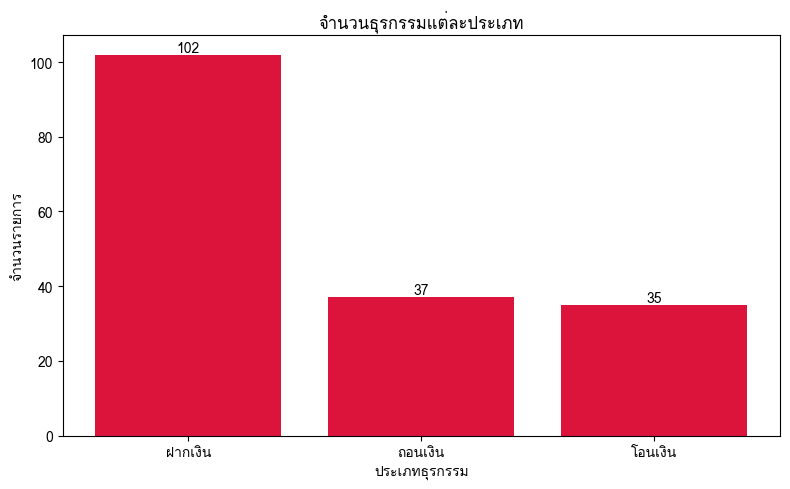


สรุปผล: ธุรกรรมที่เกิดขึ้นบ่อยที่สุดคือ ฝากเงิน จำนวน 102 รายการ
คิดเป็น 58.6 % ของธุรกรรมทั้งหมด


In [ ]:
# นับจำนวนธุรกรรมแต่ละประเภท
transaction_counts = df_clean['transaction_type'].value_counts()

# สร้างกราฟ
plt.figure(figsize=(8, 5))
bars = plt.bar(transaction_counts.index,transaction_counts.values, color = "crimson")

# แสดงจำนวนบนปลายแท่งด้วย plt.text()
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,height,str(int(height)),ha='center',va='bottom')

# ตั้งชื่อกราฟและแกน
plt.title('จำนวนธุรกรรมแต่ละประเภท')
plt.xlabel('ประเภทธุรกรรม')
plt.ylabel('จำนวนรายการ')

plt.tight_layout()
plt.show()

# สรุปผลเชื่อมโยงกับข้อมูลจริง (Bar chart)
top_type = transaction_counts.idxmax()
top_count = transaction_counts.max()
top_pct = top_count / transaction_counts.sum() * 100

print()
print("สรุปผล: ธุรกรรมที่เกิดขึ้นบ่อยที่สุดคือ", top_type, "จำนวน", top_count, "รายการ")
print("คิดเป็น", round(top_pct, 1), "% ของธุรกรรมทั้งหมด")

## **3.Line Chart**

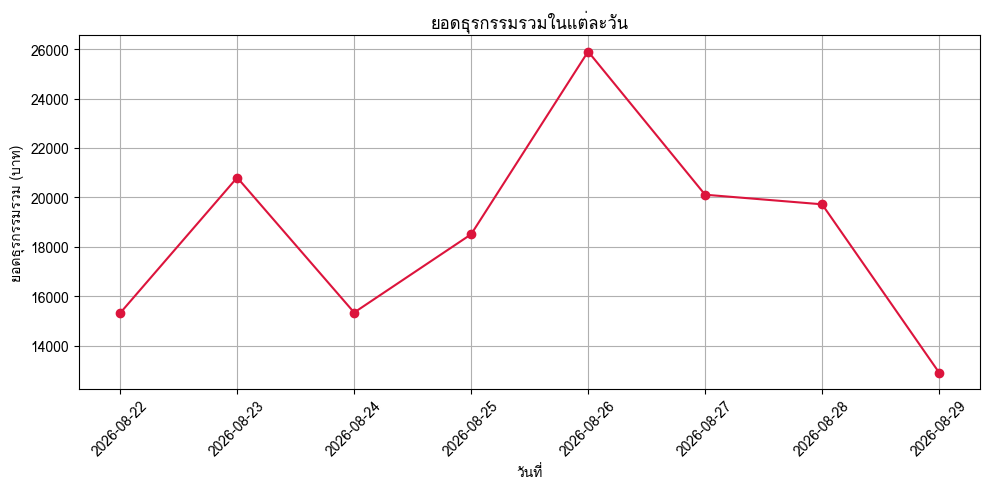


สรุปผล: วันที่มียอดธุรกรรมรวมสูงสุดคือ 26/08/2026 ด้วยยอดรวม 25901.46 บาท
วันที่มียอดธุรกรรมรวมต่ำสุดคือ 29/08/2026 ด้วยยอดรวม 12913.0 บาท
ยอดธุรกรรมรวมทั้งหมด 148612.03 บาท เฉลี่ยวันละ 18576.5 บาท


In [ ]:
# แปลงวันที่
df_clean['date'] = pd.to_datetime(df_clean['date'], dayfirst=True)

# รวมยอดเงินตามวันที่ จากข้อมูลที่ Clean แล้ว
daily_amount = df_clean.groupby('date')['amount'].sum()

# สร้างกราฟ
plt.figure(figsize=(10, 5))

# วาดเส้น
plt.plot(daily_amount.index, daily_amount.values, marker='o', color = "crimson")

# ตั้งชื่อกราฟและแกน
plt.title('ยอดธุรกรรมรวมในแต่ละวัน')
plt.xlabel('วันที่')
plt.ylabel('ยอดธุรกรรมรวม (บาท)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# สรุปผลเชื่อมโยงกับข้อมูลจริง (Line chart รวม)
max_day = daily_amount.idxmax()
max_val = daily_amount.max()
min_day = daily_amount.idxmin()
min_val = daily_amount.min()
total_amount = daily_amount.sum()
avg_amount = daily_amount.mean()

print()
print("สรุปผล: วันที่มียอดธุรกรรมรวมสูงสุดคือ", max_day.strftime('%d/%m/%Y'),
      "ด้วยยอดรวม", round(max_val, 2), "บาท")
print("วันที่มียอดธุรกรรมรวมต่ำสุดคือ", min_day.strftime('%d/%m/%Y'),
      "ด้วยยอดรวม", round(min_val, 2), "บาท")
print("ยอดธุรกรรมรวมทั้งหมด", round(total_amount, 2), "บาท เฉลี่ยวันละ", round(avg_amount, 2), "บาท")

##**4.แบบแยกแต่ละธุรกรรม**

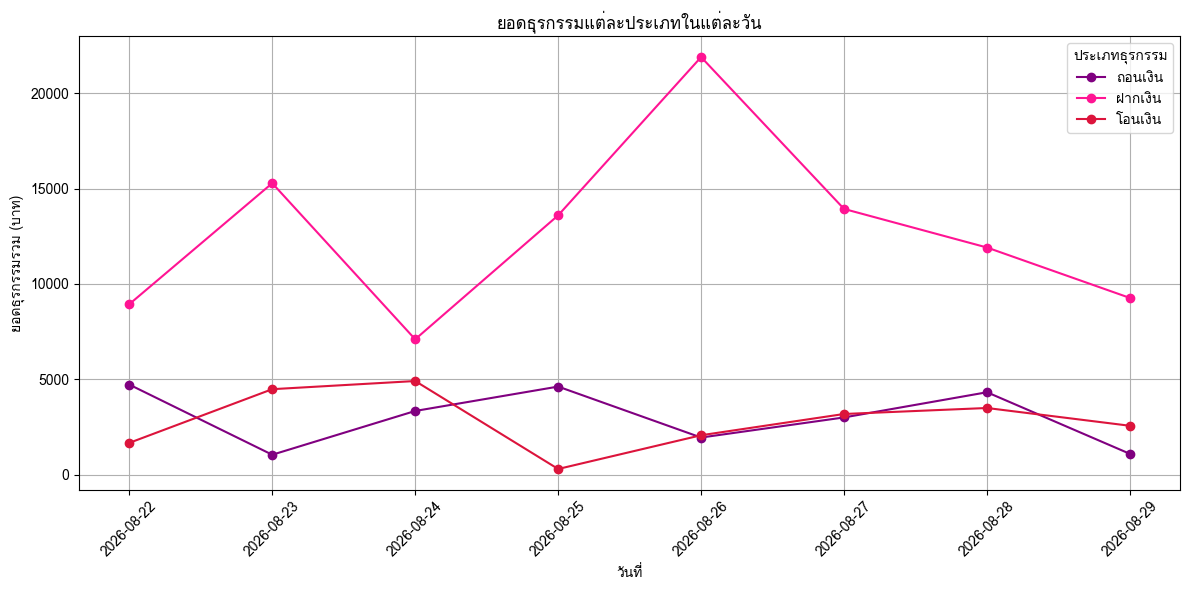


สรุปผล: บริการที่ทำรายได้สูงสุดคือ ฝากเงิน ด้วยรายได้รวม 101896.45 บาท
เปรียบเทียบยอดรวมแต่ละประเภท (บาท):
transaction_type
ฝากเงิน    101896.45
ถอนเงิน     24068.97
โอนเงิน     22646.61
dtype: float64


In [ ]:
# แปลงวันที่เป็น datetime
df_clean['date'] = pd.to_datetime(df_clean['date'], dayfirst=True)

# รวมยอดเงินแยกตามวันที่และประเภทธุรกรรม
daily_transaction = df_clean.groupby(['date', 'transaction_type'])['amount'].sum().unstack(fill_value=0)

# สีของกราฟในแต่ละธุรกรรม
colors = {
    'ถอนเงิน': 'purple',
    'ฝากเงิน': 'deeppink',
    'โอนเงิน': 'crimson'
}

# สร้างกราฟ
plt.figure(figsize=(12, 6))
for transaction in daily_transaction.columns:
    x = daily_transaction.index
    y = daily_transaction[transaction]

# วาดเส้น
    plt.plot(x,y,marker='o',label=transaction, color=colors[transaction])

# ตั้งชื่อกราฟและแกน
plt.title('ยอดธุรกรรมแต่ละประเภทในแต่ละวัน')
plt.xlabel('วันที่')
plt.ylabel('ยอดธุรกรรมรวม (บาท)')

plt.legend(title='ประเภทธุรกรรม')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# สรุปผลเชื่อมโยงกับข้อมูลจริง (Line chart แยกประเภท)
type_totals = daily_transaction.sum().sort_values(ascending=False)
top_service = type_totals.index[0]
top_revenue = type_totals.iloc[0]

print()
print("สรุปผล: บริการที่ทำรายได้สูงสุดคือ", top_service,
      "ด้วยรายได้รวม", round(top_revenue, 2), "บาท")
print("เปรียบเทียบยอดรวมแต่ละประเภท (บาท):")
print(type_totals.round(2))

## **5.Histogram**

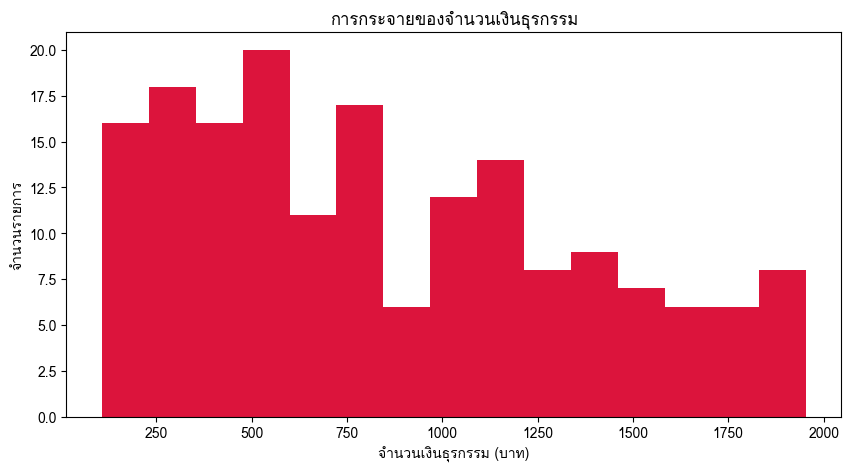


สรุปผล:
จำนวนเงินต่อธุรกรรมสูงสุด 1954.07 บาท
จำนวนเงินต่อธุรกรรมต่ำสุด 106.69 บาท
มัธยฐาน 749.46 บาท
เฉลี่ย 854.09 บาท


In [ ]:
# สร้างกราฟ
plt.figure(figsize=(10, 5))
plt.hist(df_clean['amount'], bins=15, color = "crimson")

# ตั้งชื่อกราฟและแกน
plt.title('การกระจายของจำนวนเงินธุรกรรม')
plt.xlabel('จำนวนเงินธุรกรรม (บาท)')
plt.ylabel('จำนวนรายการ')

plt.show()

# สรุปผลเชื่อมโยงกับข้อมูลจริง (Histogram)
amt_max = df_clean['amount'].max()
amt_min = df_clean['amount'].min()
amt_median = df_clean['amount'].median()
amt_mean = df_clean['amount'].mean()

print()
print("สรุปผล:")
print("จำนวนเงินต่อธุรกรรมสูงสุด", round(amt_max, 2), "บาท")
print("จำนวนเงินต่อธุรกรรมต่ำสุด", round(amt_min, 2), "บาท")
print("มัธยฐาน", round(amt_median, 2), "บาท")
print("เฉลี่ย", round(amt_mean, 2), "บาท")

# **ส่วนที่ 14 — สรุปผลการวิเคราะห์**

จากข้อมูลธุรกรรมสหกรณ์ออมทรัพย์ที่จำลองขึ้นทั้งหมด 300 รายการ
พบว่ามีธุรกรรมที่สำเร็จจำนวน 174 รายการ และไม่สำเร็จจำนวน 126 รายการ โดยธุรกรรมที่สำเร็จส่วนใหญ่เป็น การฝากเงิน 102 รายการ รองลงมาคือการถอนเงิน 37 รายการ และการโอนเงิน 35 รายการ แสดงให้เห็นว่าการฝากเงินเป็นธุรกรรมที่เกิดขึ้นมากที่สุดในข้อมูลจำลองชุดนี้ นอกจากนี้ จากกราฟเส้นพบว่ายอดธุรกรรมรวมในแต่ละวันมีความผันผวน โดยวันที่ 26 สิงหาคม 2569 มียอดธุรกรรมสูงที่สุด ขณะที่วันที่ 29 สิงหาคม 2569 มียอดต่ำที่สุด  เมื่อพิจารณาการกระจายของจำนวนเงินจาก Histogram พบว่าธุรกรรมที่สำเร็จมีจำนวนเงินตั้งแต่ประมาณ 100 ถึง 1,900 บาท และมีค่ามัธยฐานประมาณ 749.47 บาท สรุปได้ว่าในข้อมูลจำลองนี้ สหกรณ์มีการทำธุรกรรมฝากเงินเป็นหลัก และปริมาณยอดธุรกรรมมีการเปลี่ยนแปลงในแต่ละวัน โดยจำนวนเงินต่อรายการส่วนใหญ่อยู่ในระดับหลักร้อยถึงหลักพันบาท

ในมุมมองของเจ้าของสหกรณ์ ข้อมูลนี้แสดงให้เห็นว่าควรให้ความสำคัญกับการอำนวยความสะดวกและเพิ่มประสิทธิภาพในกระบวนการฝากเงิน เนื่องจากเป็นธุรกรรมที่เกิดขึ้นมากที่สุดถึง 102 รายการ ขณะเดียวกัน ธุรกรรมที่ไม่สำเร็จมีถึง 126 รายการจากทั้งหมด 300 รายการ หรือประมาณ 42% จึงควรตรวจสอบสาเหตุและหาแนวทางลดปัญหาดังกล่าว เพื่อเพิ่มประสิทธิภาพในการให้บริการ นอกจากนี้ ความผันผวนของยอดธุรกรรมในแต่ละวันสามารถนำไปใช้วางแผนการจัดสรรพนักงานและทรัพยากรให้เหมาะสมกับช่วงที่มีธุรกรรมสูงได้ และควรเก็บข้อมูลและติดตามแนวโน้มของธุรกรรมอย่างต่อเนื่อง เพื่อใช้ประกอบการวางแผนและปรับปรุงการให้บริการของสหกรณ์ในอนาคต